In [ ]:
from transformers import GPT2LMHeadModel

# size

In [42]:
model_hf = GPT2LMHeadModel.from_pretrained("gpt2") # 124M
sd_hf = model_hf.state_dict()

for k, v in sd_hf.items():
    print(f"{k:<50} {v.shape}")

transformer.wte.weight                             torch.Size([50257, 768])
transformer.wpe.weight                             torch.Size([1024, 768])
transformer.h.0.ln_1.weight                        torch.Size([768])
transformer.h.0.ln_1.bias                          torch.Size([768])
transformer.h.0.attn.c_attn.weight                 torch.Size([768, 2304])
transformer.h.0.attn.c_attn.bias                   torch.Size([2304])
transformer.h.0.attn.c_proj.weight                 torch.Size([768, 768])
transformer.h.0.attn.c_proj.bias                   torch.Size([768])
transformer.h.0.ln_2.weight                        torch.Size([768])
transformer.h.0.ln_2.bias                          torch.Size([768])
transformer.h.0.mlp.c_fc.weight                    torch.Size([768, 3072])
transformer.h.0.mlp.c_fc.bias                      torch.Size([3072])
transformer.h.0.mlp.c_proj.weight                  torch.Size([3072, 768])
transformer.h.0.mlp.c_proj.bias                    torch.Size([76

In [43]:
wte_shape = sd_hf["transformer.wte.weight"].shape
wpe_shape = sd_hf["transformer.wpe.weight"].shape

print(f"Vocabulary Size: {wte_shape[0]}")
print(f"Embedding Size: {wte_shape[1]}")
print(f"Position Size: {wpe_shape[0]}")

Vocabulary Size: 50257
Embedding Size: 768
Position Size: 1024


In [44]:
# 1. 打印Q, K, V的长度
print("=== Q, K, V的长度 ===")
# c_attn.weight的形状是 [n_embd, 3 * n_embd]，因为它将Q, K, V合并了
c_attn_shape = sd_hf["transformer.h.0.attn.c_attn.weight"].shape
n_embd = c_attn_shape[0]  # 输入嵌入维度
total_qkv_dim = c_attn_shape[1]  # 输出维度 = 3 * n_embd

# 每个Q, K, V的长度
qkv_length = total_qkv_dim // 3
print(f"输入嵌入维度 (n_embd): {n_embd}")
print(f"c_attn总输出维度: {total_qkv_dim}")
print(f"每个Q, K, V的长度: {qkv_length}")

print("\n=== 模型层数统计 ===")
# 2. 统计Attention层和MLP层的数量
attention_layers = 0
mlp_layers = 0

for key in sd_hf.keys():
    if "attn.c_attn.weight" in key:
        attention_layers += 1
    elif "mlp.c_fc.weight" in key:  # MLP的第一个线性层
        mlp_layers += 1

print(f"Attention层数量: {attention_layers}")
print(f"MLP层数量: {mlp_layers}")
print(f"总的Transformer块数量: {attention_layers}")  # 每个块包含一个attention和一个MLP

print("\n=== 输入和输出向量维度 ===")
# 3. 打印模型的输入和输出向量维度
wte_shape = sd_hf["transformer.wte.weight"].shape
wpe_shape = sd_hf["transformer.wpe.weight"].shape
lm_head_shape = sd_hf["lm_head.weight"].shape

print(f"词汇表大小 (vocab_size): {wte_shape[0]}")
print(f"输入向量维度 (embedding_dim): {wte_shape[1]}")
print(f"最大序列长度 (max_seq_len): {wpe_shape[0]}")
print(f"输出logits维度 (vocab_size): {lm_head_shape[0]}")

print("\n=== 详细信息 ===")
print(f"Token Embedding (wte): {wte_shape}")
print(f"Position Embedding (wpe): {wpe_shape}")
print(f"Language Model Head (lm_head): {lm_head_shape}")
print(f"一个注意力层的c_attn权重: {c_attn_shape}")

=== Q, K, V的长度 ===
输入嵌入维度 (n_embd): 768
c_attn总输出维度: 2304
每个Q, K, V的长度: 768

=== 模型层数统计 ===
Attention层数量: 12
MLP层数量: 12
总的Transformer块数量: 12

=== 输入和输出向量维度 ===
词汇表大小 (vocab_size): 50257
输入向量维度 (embedding_dim): 768
最大序列长度 (max_seq_len): 1024
输出logits维度 (vocab_size): 50257

=== 详细信息 ===
Token Embedding (wte): torch.Size([50257, 768])
Position Embedding (wpe): torch.Size([1024, 768])
Language Model Head (lm_head): torch.Size([50257, 768])
一个注意力层的c_attn权重: torch.Size([768, 2304])


# Word Position Embedding

`wte` 和 `wpe` 是 GPT-2 模型中两种重要的嵌入（Embedding）层，它们是模型理解输入文本的基础。

1.  **`wte` (Word Token Embedding)**
    *   这是 **词元嵌入（Token Embedding）**。
    *   它是一个巨大的查询表（lookup table）。你可以把它想象成一本字典，每一行对应一个词元（一个单词或单词的一部分），每一行都是一个长长的数字列表（向量），这个向量代表了该词元的“含义”。
    *   在你的代码中，`sd_hf["transformer.wte.weight"]` 的形状是 `[50257, 768]`，这意味着：
        *   `50257` 是词汇表的大小（Vocabulary Size），即模型认识多少个不同的词元。
        *   `768` 是嵌入的维度（Embedding Size），即用一个多长的向量来表示一个词元。

2.  **`wpe` (Word Position Embedding)**
    *   这是 **位置嵌入（Position Embedding）**。
    *   Transformer 模型本身无法感知词元的顺序。例如，对于模型来说，“猫追老鼠”和“老鼠追猫”的词元嵌入是一样的。为了解决这个问题，我们需要给模型提供位置信息。
    *   `wpe` 也是一个查询表，它的每一行代表一个位置（第0个、第1个、第2个...）。
    *   在你的代码中，`sd_hf["transformer.wpe.weight"]` 的形状是 `[1024, 768]`，这意味着：
        *   `1024` 是模型能处理的最大序列长度（Position Size）。
        *   `768` 是嵌入维度，必须和词元嵌入的维度相同。

**总结一下它们如何工作：**

当模型处理一句话时，它会为每个词元做两件事：
1.  通过 `wte` 查找到代表这个词元“含义”的向量。
2.  通过 `wpe` 查找到代表这个词元“位置”的向量。

然后，模型将这两个向量**相加**，得到一个既包含“含义”又包含“位置”信息的最终向量。这个最终的向量才是输入到 Transformer 后续网络层进行处理的真正内容。

In [45]:
import matplotlib.pyplot as plt

plt.imshow(sd_hf["transformer.wpe.weight"], cmap="gray")
# save the fig
plt.savefig("word_position_embeddings.png")

好的，这张图是GPT-2模型中**词元位置嵌入（Word Position Embedding, WPE）** 权重的热力图。我们可以从中观察到一些有趣的现象：

1.  **明显的垂直条纹**: 这是最显著的特征。这表明，对于嵌入向量中的某一个维度（即图中的某一列），它的值会随着位置（即图中的行）的变化而呈现出一种规律性的、平滑的波动。

2.  **学习到的位置信号**: GPT-2的位置嵌入是**从数据中学习**出来的，而不是像最初的Transformer论文那样使用固定的正弦/余弦函数。然而，这张图显示，模型通过学习最终得到了类似于周期性函数（如正弦波）的模式来编码位置信息。这说明，这种波动的、周期性的信号是表达序列顺序的一种非常有效的方式，以至于模型在训练中自发地“发现”了它。

3.  **每个维度都是一个独特的“时钟”**: 你可以把每一个维度（每一列）想象成一个以不同频率摆动的“时钟”。通过组合这些不同频率的“时钟”的读数，模型可以为每个位置（从0到1023）生成一个独一无二的向量表示，从而精确地知道每个词元在句子中的绝对位置和相对位置。

**总结一下**:

这张热图告诉我们，GPT-2模型学会了一种非常精巧和结构化的方式来理解单词的顺序。它没有使用杂乱无章的随机值，而是为每个位置生成了有规律的、波浪状的信号，这使得模型能够有效地处理和理解长序列文本。

In [46]:
# new fig
plt.figure(figsize=(12, 6))
plt.title("Word Position Embeddings")
plt.xlabel("Position")
plt.ylabel("Embedding Value")
#
plt.plot(sd_hf["transformer.wpe.weight"][:, 150])
plt.plot(sd_hf["transformer.wpe.weight"][:, 200])
# plt.plot(sd_hf["transformer.wpe.weight"][:, 361])
plt.plot(sd_hf["transformer.wpe.weight"][:, 700])
# save the fig
plt.savefig("cols_of_word_position_embeddings.png")


周期性最强的前5列是: [497 762 724 459 361]


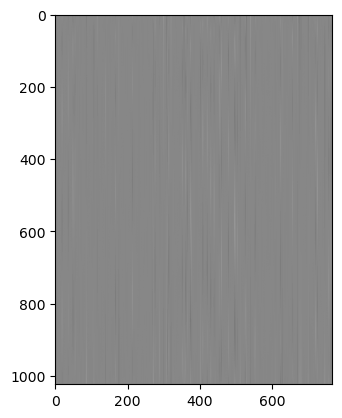

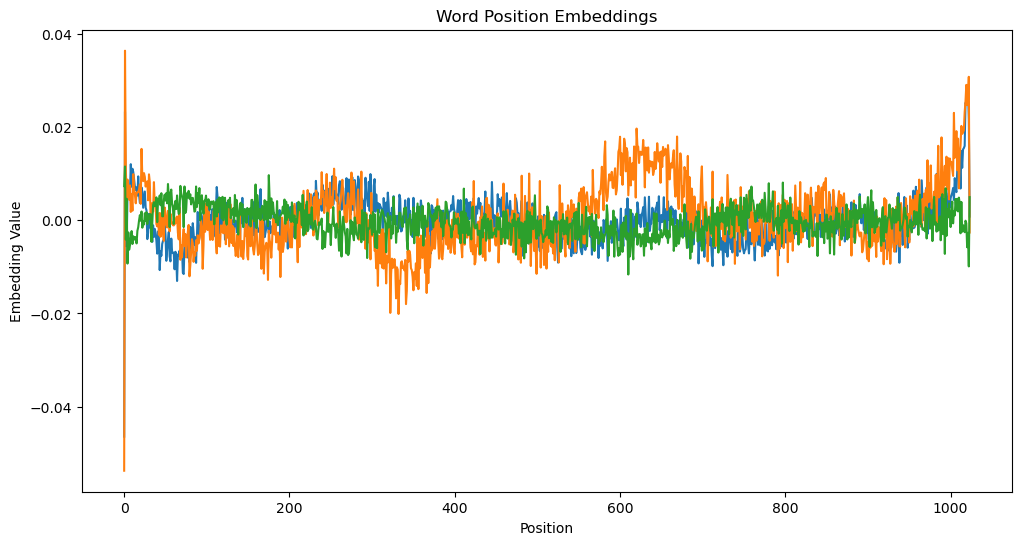

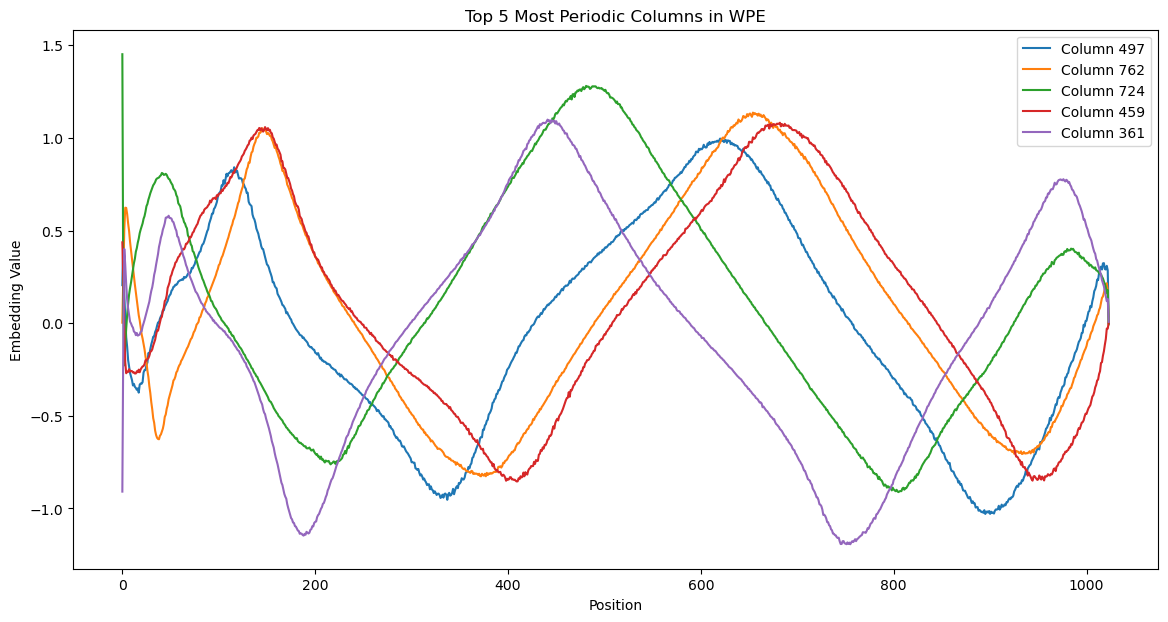

In [47]:
import numpy as np
import matplotlib.pyplot as plt

# 获取WPE权重并转换为numpy数组
wpe_weights = sd_hf["transformer.wpe.weight"].numpy()
n_positions, n_dims = wpe_weights.shape

# --- 找到周期性最强的前5列 ---

# 存储每一列的峰值幅度
peak_magnitudes = []

# 遍历每一列（每一个嵌入维度）
for i in range(n_dims):
    col = wpe_weights[:, i]
    
    # 进行快速傅里叶变换 (FFT)
    fft_vals = np.fft.fft(col)
    
    # 计算频率的幅度（忽略直流分量）
    fft_magnitudes = np.abs(fft_vals[1:n_positions//2])
    
    # 找到当前列的最大峰值
    current_max_peak = np.max(fft_magnitudes)
    peak_magnitudes.append(current_max_peak)

# 获取峰值幅度最高的5列的索引
# np.argsort会返回排序后的索引，我们取最后5个
top_5_indices = np.argsort(peak_magnitudes)[-5:]

print(f"周期性最强的前5列是: {top_5_indices}")

# --- 可视化这5列 ---
plt.figure(figsize=(14, 7))
plt.title("Top 5 Most Periodic Columns in WPE")
plt.xlabel("Position")
plt.ylabel("Embedding Value")

for idx in top_5_indices:
    plt.plot(wpe_weights[:, idx], label=f'Column {idx}')

plt.legend()
plt.show()

周期性最强的前5列是: [497 762 724 459 361]
周期性处于中位数附近的5列是: [143 298 689 124 590]


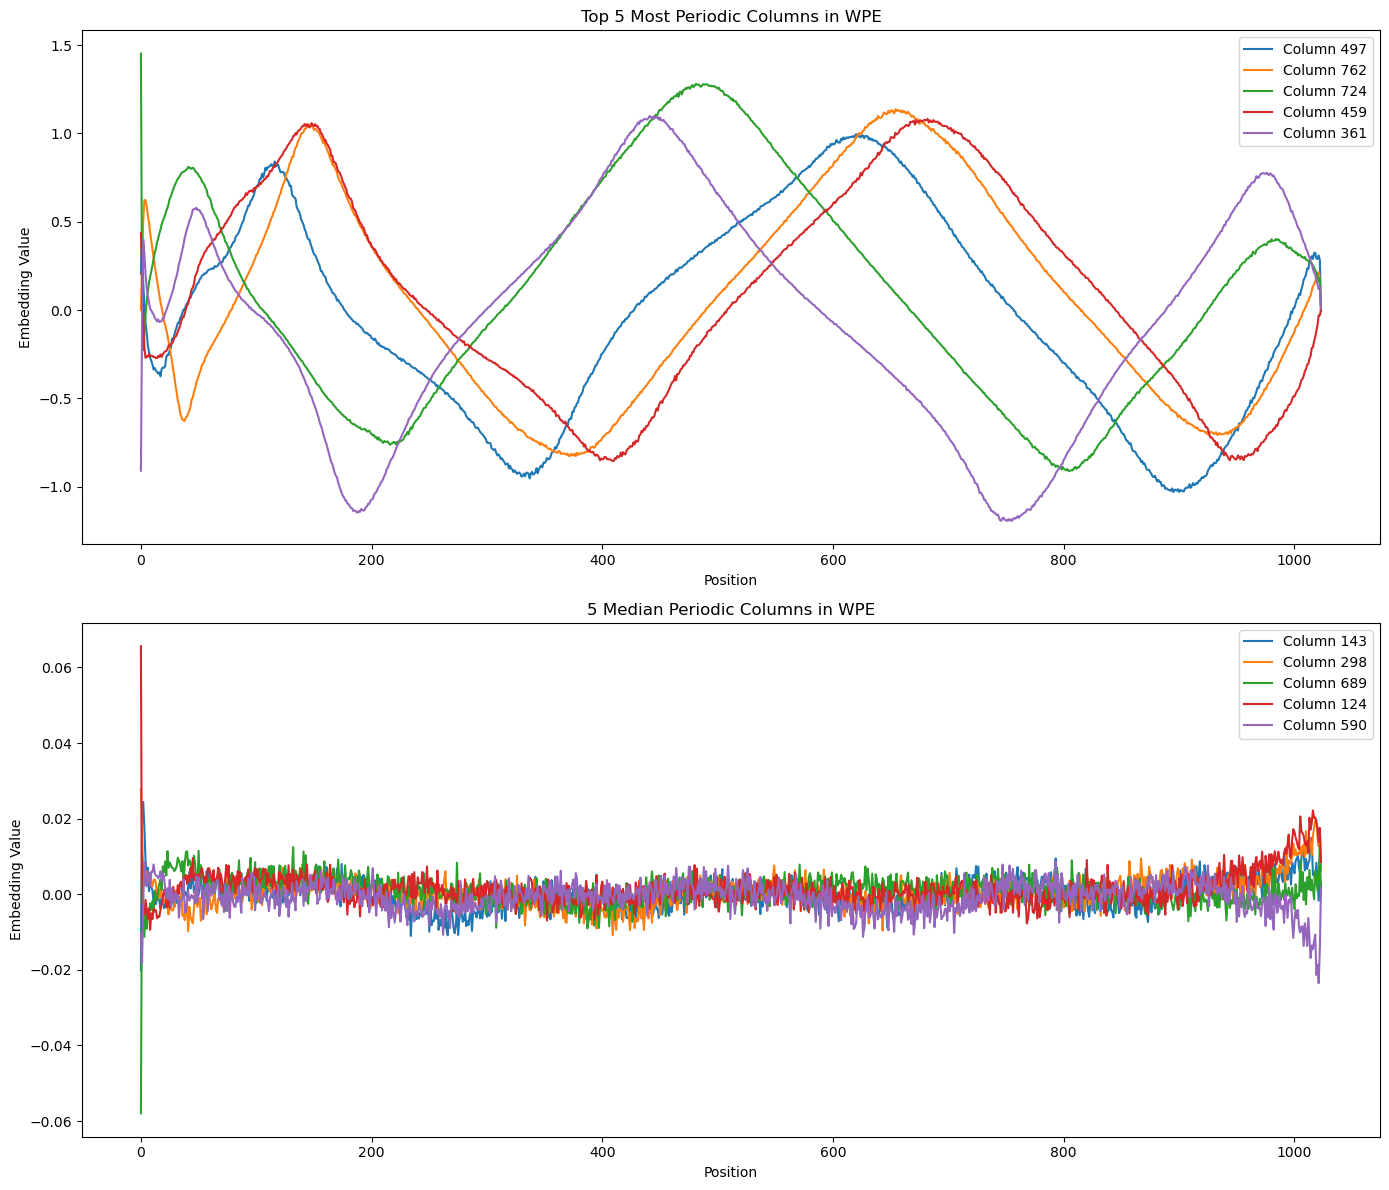

In [48]:
import numpy as np
import matplotlib.pyplot as plt

# 获取WPE权重并转换为numpy数组
wpe_weights = sd_hf["transformer.wpe.weight"].numpy()
n_positions, n_dims = wpe_weights.shape

# --- 对每一列进行FFT并找到峰值幅度 ---
peak_magnitudes = []
for i in range(n_dims):
    col = wpe_weights[:, i]
    fft_vals = np.fft.fft(col)
    fft_magnitudes = np.abs(fft_vals[1:n_positions//2])
    peak_magnitudes.append(np.max(fft_magnitudes))

# --- 获取排序后的索引 ---
# sorted_indices[0] 是周期性最弱的列的索引
# sorted_indices[-1] 是周期性最强的列的索引
sorted_indices = np.argsort(peak_magnitudes)

# --- 找到周期性最强和中位数的列索引 ---
top_5_indices = sorted_indices[-5:]
median_point = n_dims // 2
# 取中位数附近的5个
median_5_indices = sorted_indices[median_point-2 : median_point+3]

print(f"周期性最强的前5列是: {top_5_indices}")
print(f"周期性处于中位数附近的5列是: {median_5_indices}")


# --- 可视化 ---
plt.figure(figsize=(14, 12))

# 图1: 周期性最强的5列
plt.subplot(2, 1, 1)
plt.title("Top 5 Most Periodic Columns in WPE")
plt.xlabel("Position")
plt.ylabel("Embedding Value")
for idx in top_5_indices:
    plt.plot(wpe_weights[:, idx], label=f'Column {idx}')
plt.legend()

# 图2: 周期性中位数的5列
plt.subplot(2, 1, 2)
plt.title("5 Median Periodic Columns in WPE")
plt.xlabel("Position")
plt.ylabel("Embedding Value")
for idx in median_5_indices:
    plt.plot(wpe_weights[:, idx], label=f'Column {idx}')
plt.legend()

plt.tight_layout()
plt.show()

In [49]:
# new fig
plt.figure(figsize=(12, 6))
plt.title("Word Position Embeddings")
plt.xlabel("Position")
plt.ylabel("Embedding Value")
#
# plt.plot(sd_hf["transformer.wpe.weight"][0, :])
plt.plot(sd_hf["transformer.wpe.weight"][100, :])
# plt.plot(sd_hf["transformer.wpe.weight"][250, :])
# plt.plot(sd_hf["transformer.wpe.weight"][700, :])
# save the fig
plt.savefig("rows_of_word_position_embeddings.png")

周期性最强的前5列是: [4 3 2 1 0]


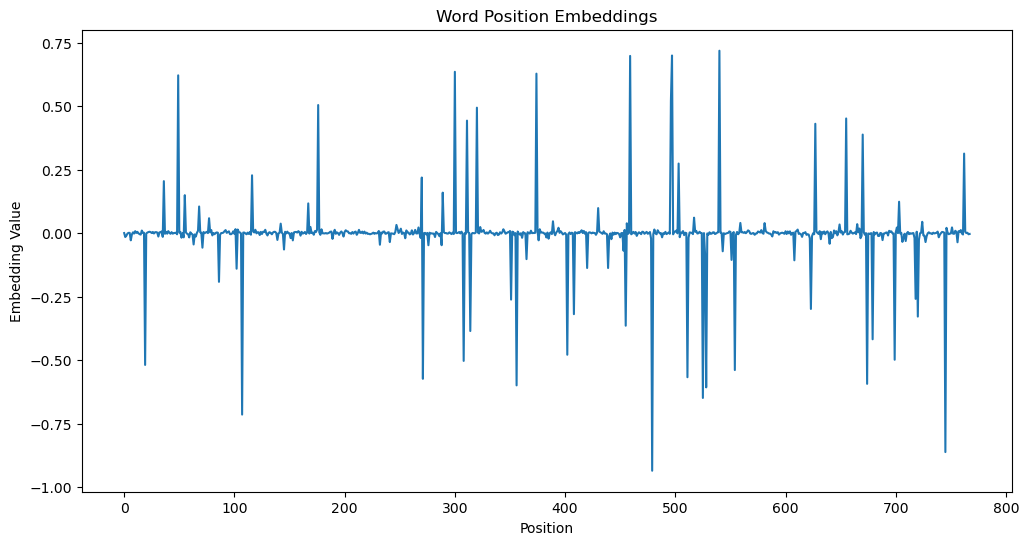

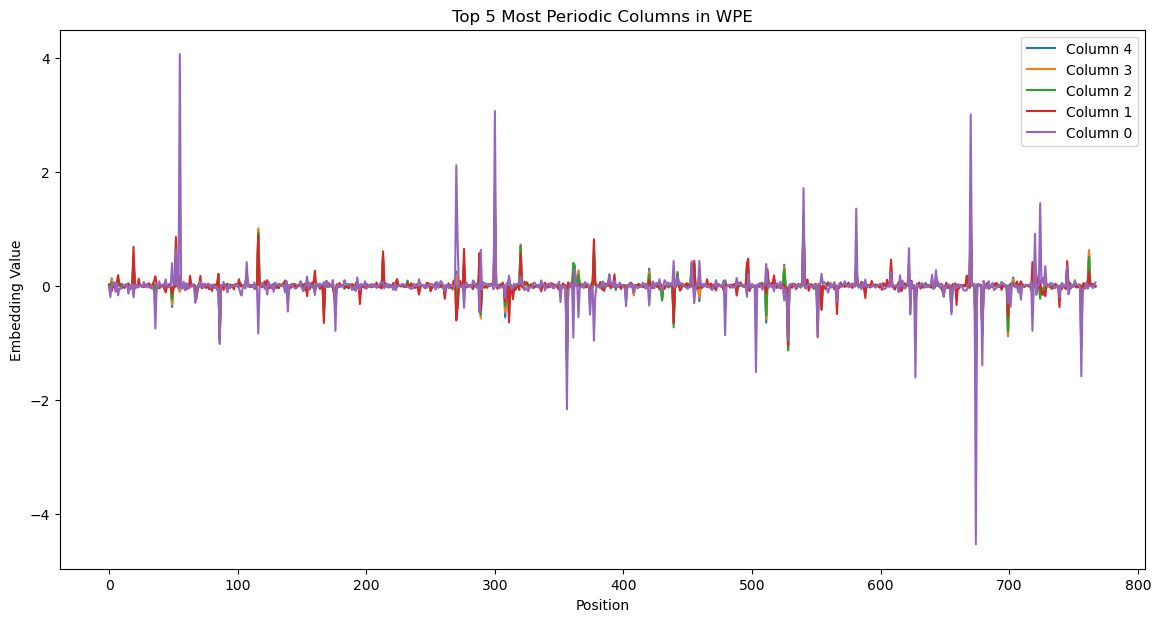

In [50]:
import numpy as np
import matplotlib.pyplot as plt

# 获取WPE权重并转换为numpy数组
wpe_weights = sd_hf["transformer.wpe.weight"].numpy()
wpe_weights = wpe_weights.T
n_positions, n_dims = wpe_weights.shape

# --- 找到周期性最强的前5列 ---

# 存储每一列的峰值幅度
peak_magnitudes = []

# 遍历每一列（每一个嵌入维度）
for i in range(n_dims):
    col = wpe_weights[:, i]
    
    # 进行快速傅里叶变换 (FFT)
    fft_vals = np.fft.fft(col)
    
    # 计算频率的幅度（忽略直流分量）
    fft_magnitudes = np.abs(fft_vals[1:n_positions//2])
    
    # 找到当前列的最大峰值
    current_max_peak = np.max(fft_magnitudes)
    peak_magnitudes.append(current_max_peak)

# 获取峰值幅度最高的5列的索引
# np.argsort会返回排序后的索引，我们取最后5个
top_5_indices = np.argsort(peak_magnitudes)[-5:]

print(f"周期性最强的前5列是: {top_5_indices}")

# --- 可视化这5列 ---
plt.figure(figsize=(14, 7))
plt.title("Top 5 Most Periodic Columns in WPE")
plt.xlabel("Position")
plt.ylabel("Embedding Value")

for idx in top_5_indices:
    plt.plot(wpe_weights[:, idx], label=f'Column {idx}')

plt.legend()
plt.show()

“周期性”最强的前5行是: [4 3 2 1 0]


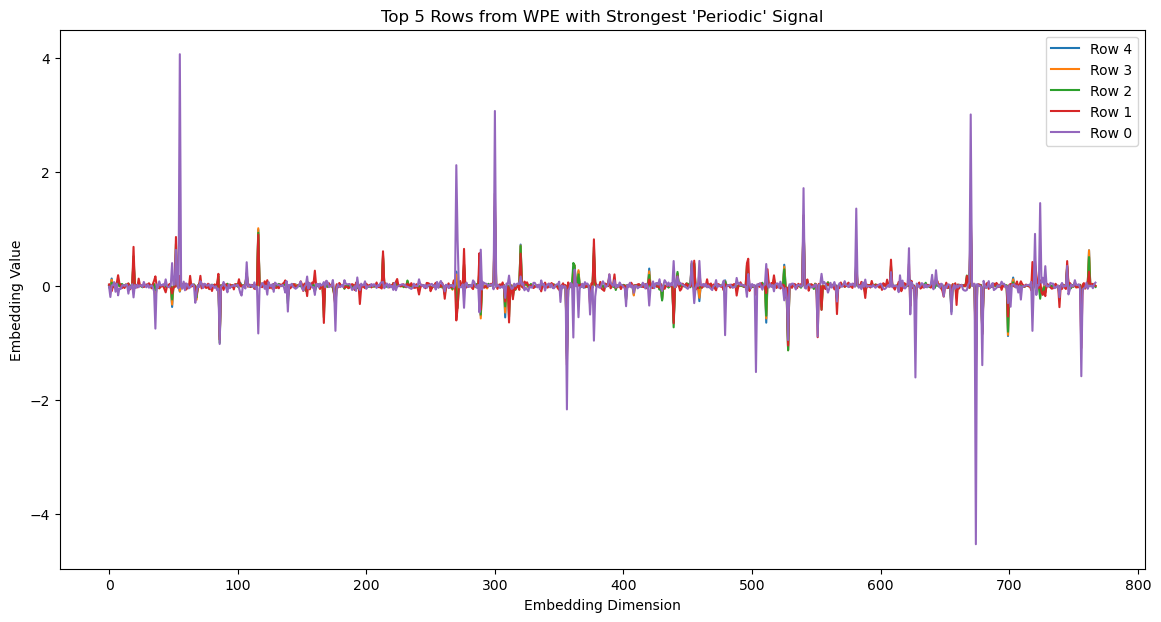

In [51]:
import numpy as np
import matplotlib.pyplot as plt

# 获取WPE权重并转换为numpy数组
wpe_weights = sd_hf["transformer.wpe.weight"].numpy()
n_positions, n_dims = wpe_weights.shape

# --- 找到“周期性”最强的前5行 ---
# 注意：对行进行傅里叶分析的物理意义不如对列清晰，
# 因为行的维度是嵌入维度，而不是时间或空间序列。
# 但我们仍然可以执行相同的数学操作。

# 存储每一行的峰值幅度
peak_magnitudes = []

# 遍历每一行（每一个位置）
for i in range(n_positions):
    row = wpe_weights[i, :]
    
    # 进行快速傅里叶变换 (FFT)
    fft_vals = np.fft.fft(row)
    
    # 计算频率的幅度（忽略直流分量）
    fft_magnitudes = np.abs(fft_vals[1:n_dims//2])
    
    # 找到当前行的最大峰值
    current_max_peak = np.max(fft_magnitudes)
    peak_magnitudes.append(current_max_peak)

# 获取峰值幅度最高的5行的索引
top_5_indices = np.argsort(peak_magnitudes)[-5:]

print(f"“周期性”最强的前5行是: {top_5_indices}")

# --- 可视化这5行 ---
plt.figure(figsize=(14, 7))
plt.title("Top 5 Rows from WPE with Strongest 'Periodic' Signal")
plt.xlabel("Embedding Dimension")
plt.ylabel("Embedding Value")

for idx in top_5_indices:
    plt.plot(wpe_weights[idx, :], label=f'Row {idx}')

plt.legend()
plt.show()

你观察到的现象非常有趣，这揭示了高维嵌入向量的一个核心特点。这张图展示的是**某一个固定位置**（例如，第100个位置）的嵌入向量，它有768个维度。

之所以某一行会长这样，有很多尖峰，主要有以下几个原因：

1.  **为了独特性和可区分性 (Uniqueness and Distinguishability)**：
    *   模型的首要任务是为每一个位置（从0到1023）生成一个**独一无二的“指纹”**。
    *   在一个高维空间（这里是768维）中，最有效的方式不是让所有维度的值都平滑分布，而是在少数几个维度上拥有非常突出（或正或负）的值，而其他大部分维度的值都接近于零。
    *   这些**尖峰**就像这个位置“指纹”上最关键的特征点。正是这些尖峰的位置和高度，让位置100的向量与位置101的向量能够被模型清晰地区分开。

2.  **学习到的特征表示 (Learned Feature Representation)**：
    *   这些尖峰不是随机的。模型在训练中发现，激活某些特定的维度（即产生尖峰）对于编码位置信息最有效。
    *   你可以把每个维度想象成一个特征。一个尖峰意味着对于当前这个位置，模型认为“激活”这个特征非常重要。

3.  **稀疏性 (Sparsity)**：
    *   这种大部分值接近零、少数有尖峰的模式，是一种**稀疏表示**。在神经网络中，稀疏表示被认为是一种高效的编码信息的方式。它能用更少的“能量”（非零值）来存储和区分信息。

**总结一下**：

把WPE矩阵的**行**和**列**对比来看，会非常有启发性：

*   **看一列**：我们看到的是一个**平滑的、类似周期函数的波**。它表示一个**特征维度**是如何随着**位置**变化来编码信息的。
*   **看一行**：我们看到的是一个**带有尖峰的、类似噪声的信号**。它表示一个**固定位置**是如何通过在768个**特征维度**上进行组合，来创造一个**独一无二的身份标识**的。

所以，这些尖峰正是模型为区分不同位置而学习到的、最关键的“密码”。

总之，GPT2的WPE:

1. 多数列（>50%）的振幅很小。小于0.04。
2. 少数列（<50%）的振幅很大。并且呈现周期性。

# Attention

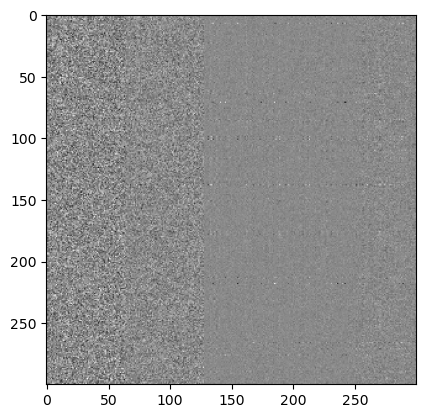

In [ ]:
test = sd_hf["transformer.h.1.attn.c_attn.weight"]
plt.imshow(test[:300,:300], cmap="gray")

# save the fig
plt.savefig("attention_weights.png")

plt.show()

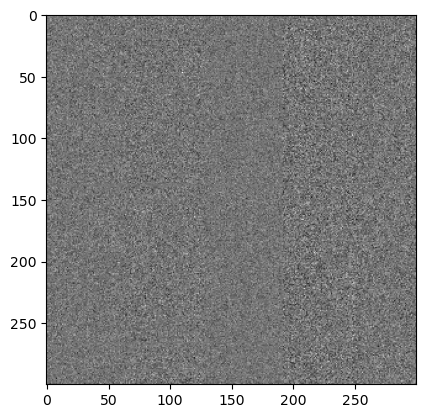

In [53]:
test = sd_hf["transformer.h.0.attn.c_attn.weight"]
plt.imshow(test[:300,:300], cmap="gray")

# save the fig
plt.savefig("attention_weights.png")

plt.show()

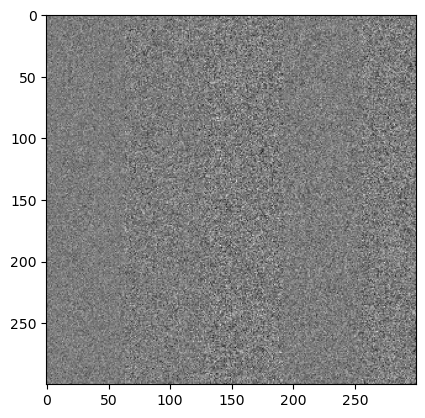

In [54]:
test = sd_hf["transformer.h.2.attn.c_attn.weight"]
plt.imshow(test[:300,:300], cmap="gray")

# save the fig
plt.savefig("attention_weights.png")

plt.show()

In [55]:
from transformers import pipeline, set_seed
generator = pipeline('text-generation', model='gpt2')
set_seed(42)
generator("Hello, I'm a language model,", max_length=30, num_return_sequences=5)


Device set to use cpu
Truncation was not explicitly activated but `max_length` is provided a specific value, please use `truncation=True` to explicitly truncate examples to max length. Defaulting to 'longest_first' truncation strategy. If you encode pairs of sequences (GLUE-style) with the tokenizer you can select this strategy more precisely by providing a specific strategy to `truncation`.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


[{'generated_text': "Hello, I'm a language model, but what I'm really doing is making a human-readable document. There are other languages, but those are"},
 {'generated_text': "Hello, I'm a language model, not a syntax model. That's why I like it. I've done a lot of programming projects.\n"},
 {'generated_text': "Hello, I'm a language model, and I'll do it in no time!\n\nOne of the things we learned from talking to my friend"},
 {'generated_text': "Hello, I'm a language model, not a command line tool.\n\nIf my code is simple enough:\n\nif (use (string"},
 {'generated_text': "Hello, I'm a language model, I've been using Language in all my work. Just a small example, let's see a simplified example."}]

In [56]:
# let's instead sample manually
import torch
from torch.nn import functional as F

model = GPT2LMHeadModel.from_pretrained("gpt2") # 124M
model.eval()
model.to('cuda')
torch.manual_seed(42)
torch.cuda.manual_seed(42)
tokens = [15496, 11, 314, 1101, 257, 3303, 2746, 11] # "Hello, I'm a language model,"
tokens = torch.tensor(tokens, dtype=torch.long) # (8,)
tokens = tokens.unsqueeze(0).repeat(5, 1) # (5, 8)
x = tokens.to('cuda')

# generate!
while x.size(1) < 30: # max_length=30
    # forward the model to get the logits
    with torch.no_grad():
        logits = model(x)[0] # (B, T, vocab_size)
        # take the logits at the last position
        logits = logits[:, -1, :] # (B, vocab_size)
        # get the probabilities
        probs = F.softmax(logits, dim=-1)
        # do top-k sampling of 50 (huggingface pipeline default)
        # topk_probs here becomes (5, 50), topk_indices is (5, 50)
        topk_probs, topk_indices = torch.topk(probs, 50, dim=-1)
        # select a token from the top-k probabilities
        # note: multinomial does not demand the input to sum to 1
        ix = torch.multinomial(topk_probs, 1) # (B, 1)
        # gather the corresponding indices
        xcol = torch.gather(topk_indices, -1, ix) # (B, 1)
        # append to the sequence
        x = torch.cat((x, xcol), dim=1)

# print the generated text
import tiktoken
enc = tiktoken.get_encoding('gpt2')
for i in range(5):
    tokens = x[i, :30].tolist()
    decoded = enc.decode(tokens)
    print(">", decoded)

AssertionError: Torch not compiled with CUDA enabled

In [ ]:
# tiny shakespeare dataset
# !wget https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt
with open('input.txt', 'r') as f:
    text = f.read()
data = text[:1000] # first 1,000 characters
print(data[:100])

In [ ]:
import tiktoken
enc = tiktoken.get_encoding('gpt2')
tokens = enc.encode(data)
print(tokens[:24])

In [ ]:
import torch
buf = torch.tensor(tokens[:24 + 1])
x = buf[:-1].view(4, 6)
y = buf[1:].view(4, 6)
print(x)
print(y)

In [ ]:
print(sd_hf["lm_head.weight"].shape)
print(sd_hf["transformer.wte.weight"].shape)

In [ ]:
(sd_hf["lm_head.weight"] == sd_hf["transformer.wte.weight"]).all()

In [ ]:
print(sd_hf["lm_head.weight"].data_ptr())
print(sd_hf["transformer.wte.weight"].data_ptr())

In [ ]:

# standard deviation grows inside the residual stream
x = torch.zeros(768)
n = 100 # e.g. 100 layers
for i in range(n):
    x += n**-0.5 * torch.randn(768)

print(x.std())

In [ ]:
import torch

# super simple little MLP
net = torch.nn.Sequential(
    torch.nn.Linear(16, 32),
    torch.nn.GELU(),
    torch.nn.Linear(32, 1)
)
torch.random.manual_seed(42)
x = torch.randn(4, 16)
y = torch.randn(4, 1)
net.zero_grad()
yhat = net(x)
loss = torch.nn.functional.mse_loss(yhat, y)
loss.backward()
print(net[0].weight.grad.view(-1)[:10])

# the loss objective here is (due to readuction='mean')
# L = 1/4 * [
#            (y[0] - yhat[0])**2 +
#            (y[1] - yhat[1])**2 +
#            (y[2] - yhat[2])**2 +
#            (y[3] - yhat[3])**2
#           ]
# NOTE: 1/4!

In [ ]:
# now let's do it with grad_accum_steps of 4, and B=1
# the loss objective here is different because
# accumulation in gradient <---> SUM in loss
# i.e. we instead get:
# L0 = 1/4(y[0] - yhat[0])**2
# L1 = 1/4(y[1] - yhat[1])**2
# L2 = 1/4(y[2] - yhat[2])**2
# L3 = 1/4(y[3] - yhat[3])**2
# L = L0 + L1 + L2 + L3
# NOTE: the "normalizer" of 1/4 is lost
net.zero_grad()
for i in range(4):
    yhat = net(x[i])
    loss = torch.nn.functional.mse_loss(yhat, y[i])
    loss = loss / 4 # <-- have to add back the "normalizer"!
    loss.backward()
print(net[0].weight.grad.view(-1)[:10])


In [ ]:
# parse and visualize the logfile
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

sz = "124M"

loss_baseline = {
    "124M": 3.2924,
}[sz]
hella2_baseline = { # HellaSwag for GPT-2
    "124M": 0.294463,
    "350M": 0.375224,
    "774M": 0.431986,
    "1558M": 0.488946,
}[sz]
hella3_baseline = { # HellaSwag for GPT-3
    "124M": 0.337,
    "350M": 0.436,
    "774M": 0.510,
    "1558M": 0.547,
}[sz]

# load the log file
with open("log124M_40B/log.txt", "r") as f:
    lines = f.readlines()

# parse the individual lines, group by stream (train,val,hella)
streams = {}
for line in lines:
    step, stream, val = line.strip().split()
    if stream not in streams:
        streams[stream] = {}
    streams[stream][int(step)] = float(val)

# convert each stream from {step: val} to (steps[], vals[])
# so it's easier for plotting
streams_xy = {}
for k, v in streams.items():
    # get all (step, val) items, sort them
    xy = sorted(list(v.items()))
    # unpack the list of tuples to tuple of lists
    streams_xy[k] = list(zip(*xy))

# create figure
plt.figure(figsize=(16, 6))

# Panel 1: losses: both train and val
plt.subplot(121)
xs, ys = streams_xy["train"] # training loss
ys = np.array(ys)
plt.plot(xs, ys, label=f'nanogpt ({sz}) train loss')
print("Min Train Loss:", min(ys))
xs, ys = streams_xy["val"] # validation loss
plt.plot(xs, ys, label=f'nanogpt ({sz}) val loss')
# horizontal line at GPT-2 baseline
if loss_baseline is not None:
    plt.axhline(y=loss_baseline, color='r', linestyle='--', label=f"OpenAI GPT-2 ({sz}) checkpoint val loss")
plt.xlabel("steps")
plt.ylabel("loss")
plt.yscale('log')
plt.ylim(top=4.0)
plt.legend()
plt.title("Loss")
print("Min Validation Loss:", min(ys))

# Panel 2: HellaSwag eval
plt.subplot(122)
xs, ys = streams_xy["hella"] # HellaSwag eval
ys = np.array(ys)
plt.plot(xs, ys, label=f"nanogpt ({sz})")
# horizontal line at GPT-2 baseline
if hella2_baseline:
    plt.axhline(y=hella2_baseline, color='r', linestyle='--', label=f"OpenAI GPT-2 ({sz}) checkpoint")
if hella3_baseline:
    plt.axhline(y=hella3_baseline, color='g', linestyle='--', label=f"OpenAI GPT-3 ({sz}) checkpoint")
plt.xlabel("steps")
plt.ylabel("accuracy")
plt.legend()
plt.title("HellaSwag eval")
print("Max Hellaswag eval:", max(ys))